In [43]:
## synteny_figures.R
## Enhancer-gene synteny conservation across VGP Species
##
## Step 0 assumes you have run the liftover array job and have:
##   liftover_out/<GENOME>/closest.bed   (bedtools closest -D ref output)
##   liftover_out/<GENOME>/results.tsv   (genome, peak_id, nearest_gene, pct_lifted)
##
## Run this script FIRST in a shell to rebuild results.tsv with distance included:
##   bash fix_extract_distance.sh
## (generated at the bottom of this header as a heredoc — see Step 0 notes)

suppressPackageStartupMessages({
  library(here)
  library(tidyverse)
  library(data.table)
  library(ggplot2)
  library(ggbeeswarm)
  library(ggrepel)
  library(patchwork)
})


DATADIR="/Aging/LQ_TACIT/data/"
PLOTDIR="/Aging/LQ_TACIT/plots/VGP/"

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 0  — load meta + add DivTime
# ══════════════════════════════════════════════════════════════════════════════

meta <- read_tsv(
    "/evolution/VLTacit/data/raw_data/synteny_data/vgp_metadata.tsv",
  col_types   = cols(.default = "c"),
  name_repair = "unique_quiet") %>%
  dplyr::select(
    accession = `Accession # for main haplotype`,
    Assembly_ID      = `Assembly ID`,
    Lineage     = `Lineage`,
    Superorder  = `Superorder`,  
    Order  = `Orders English Name`,
    Species = `Scientific Name`,  
    MYA_Ordinal = `MYA div closest ordinal relative`
  ) %>% 
filter(!is.na(accession), accession != "") %>%
mutate(
    MYA_Ordinal = suppressWarnings(as.numeric(MYA_Ordinal)),
    Clade = case_when(
      Lineage == "Mammals"    ~ "Mammals",
      Lineage == "Birds"      ~ "Birds",
      Lineage == "Reptiles"   ~ "Reptiles",
      Lineage == "Amphibians" ~ "Amphibians",
      str_detect(Lineage, regex("fish|actino|chondri", ignore_case = TRUE)) ~ "Fish",
      TRUE ~ "Other"),
      Clade = factor(Clade, levels = c("Mammals","Birds","Reptiles","Amphibians","Fish","Other"))) %>% 
mutate(
    accession_base = accession %>%
      str_remove("\\.\\d+$") %>%
      str_replace("^GCF_", "GCA_"))

# VGP DivTime from TimeTree + PAReTT
vgp = read_csv(paste0(DATADIR,"VGP_579_NamesList_DivTime.txt"))[2:3]
vgp = as.data.frame(vgp[order(vgp$Div.Time.MYA),])

meta = left_join(meta, vgp, by='Species')

Rows: 579 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Reference, Species
dbl (1): Div.Time.MYA

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [74]:
# writeLines(meta$accession, paste0(DATADIR,"VGP_579_accession.txt"))

# Extra 
# Assembly ID to Species name from NCBI

# To get accession from NCBI
#conda install -c conda-forge ncbi-datasets-cli
#datasets summary genome accession --inputfile /Aging/LQ_TACIT/data/VGP_579_accession.txt --as-json-lines | dataformat tsv genome --fields accession,organism-name > /Aging/LQ_TACIT/data/VGP_579_accession_NamesList.txt

accession = read.delim(paste0(DATADIR,"VGP_579_accession_NamesList.txt"))
colnames(accession) = c('accession', 'Species')

# VGP DivTime from TimeTree + PAReTT
vgp = read_csv(paste0(DATADIR,"VGP_577_NamesList_DivTime.txt"))[2:3]
vgp = as.data.frame(vgp[order(vgp$Div.Time.MYA),])
vgp = left_join(accession, vgp, by='Species')
vgp$Species = gsub(" ", "_", vgp$Species)

# Zoonomia DivTime from TimeTree + PAReTT 
znm = read.delim(paste0(DATADIR,"Zoonomia_240_NamesList_DivTime.txt"))[c(1,3)]
colnames(znm) = c('Species', 'Div.Time.MYA')
znm = znm[order(znm$Div.Time.MYA),]
rownames(znm) = NULL

#left_join(vgp, znm, by='Species')
#length(intersect(vgp$Species, znm$Species)) # only 55 Species

Rows: 579 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Reference, Species
dbl (1): Div.Time.MYA

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [37]:
OUTDIR=paste0(DATADIR,"liftover_out_vuln/")
REFDIR=paste0(DATADIR,"liftover_out_vuln/reference/")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1  — hg38 reference gene labels (from precomputed TSV)
# ══════════════════════════════════════════════════════════════════════════════

ref_labels <- readr::read_tsv(
  paste0(REFDIR,"peakAnno_hg38.tsv"),
  col_names = c("peak_id", "genome", "gene", "distanceToTSS"),
  col_types = cols(
    peak_id = col_character(),
    genome = col_character(),
    gene = col_character(),
    distanceToTSS = col_double()
  )
) %>%
  filter(genome == "hg38") %>%
  transmute(
    peak_id,
    ref_gene = gene,
    ref_dist = distanceToTSS
  ) %>%
  filter(!is.na(ref_gene))

cat("Reference peaks with gene labels:", nrow(ref_labels), "\n")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2  — load combined liftover results
# ══════════════════════════════════════════════════════════════════════════════

closest_all <- read_tsv(
  paste0(OUTDIR,"closest_all.tsv"),
  col_names = c("accession", "peak_id", "nearest_gene", "distance_bp", "pct_lifted"),
  col_types  = "cccdc"
) %>%
  mutate(
    pct_lifted = as.numeric(pct_lifted),
    # normalize: strip version, convert GCF → GCA
    accession_base = accession %>%
      str_remove("\\.\\d+$") %>%
      str_replace("^GCF_", "GCA_")
  ) %>%
  dplyr::filter(!str_detect(accession, "Anc\\d+$")) %>%
  left_join(
    dplyr::select(meta, accession_base, Lineage, Clade, Order, Species, Div.Time.MYA),
    by = c("accession_base")
  )

# Check
cat("Unmatched genomes:", closest_all %>% dplyr::filter(is.na(Clade)) %>% pull(accession) %>% n_distinct(), "\n")
closest_all %>% count(Clade)

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3  — score synteny (gene name match) + compute distance shift
# ══════════════════════════════════════════════════════════════════════════════
synteny <- closest_all %>%
  inner_join(ref_labels, by = "peak_id") %>%
  mutate(
    synteny_retained = case_when(
      nearest_gene == "." | is.na(nearest_gene) ~ NA,
      nearest_gene == ref_gene                  ~ TRUE,
      TRUE                                      ~ FALSE
    ),
    # distance shift: how much did the enhancer move relative to its hg38 anchor?
    # positive = moved further, negative = moved closer
    abs_dist_bp   = abs(distance_bp),
    dist_shift_bp = abs_dist_bp - abs(ref_dist)
  )

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4  — per-Species summaries
# ══════════════════════════════════════════════════════════════════════════════
Species_stats <- synteny %>%
  filter(!is.na(synteny_retained)) %>%
  group_by(accession_base) %>%
  summarise(
    n_peaks           = n(),
    pct_retained      = 100 * mean(synteny_retained),
    median_abs_dist   = median(abs_dist_bp, na.rm = TRUE),
    median_dist_shift = median(dist_shift_bp, na.rm = TRUE),
    pct_lifted        = dplyr::first(pct_lifted),   # explicit namespace
    .groups           = "drop"
  ) %>%
  left_join(meta, by = "accession_base") %>% na.omit() # meta 


cat("Species with synteny data:", nrow(Species_stats), "\n")
cat("Species with synteny data:", length(unique(Species_stats$accession_base)), "\n")

Reference peaks with gene labels: 427 
Unmatched genomes: 8 


Clade,n
<fct>,<int>
Mammals,1227146
Birds,252895
Reptiles,97525
Amphibians,11489
Fish,23805
Other,109
NA,47780


Species with synteny data: 541 
Species with synteny data: 541 


In [31]:
# list of genesets 

# ------------- Aging Signatures -------------

# ENR Results

dir = '/Aging/'
geneset <- read.csv(paste0(dir,"ENR_Age_Prediction/Output/24_10_02_model_M24_coef_gene_filtering_mean_age_corrected_pred_age.csv"), row.names = 1)
# M24
geneset_pos24 <- rownames(subset(geneset, M_24 > 0))
geneset_neg24 <- rownames(subset(geneset, M_24 < 0))
# MO -- subset top n number of genes -- n = number of genes from last model 
geneset_pos <- subset(geneset, M_0 > 0)
geneset_pos0 <- rownames(geneset_pos[order(geneset_pos$M_0, decreasing = T),])[1:length(geneset_pos24)]
geneset_neg <- subset(geneset, M_0 < 0)
geneset_neg0 <- rownames(geneset_neg[order(geneset_neg$M_0, decreasing = F),])[1:length(geneset_neg24)]
# ---------------------------------------------------------------------------------------------------------------------------------

# OLS Results

dir = '/Aging/Aging_Clock/Output/'

geneset <- read.csv(paste0(dir,"25_02_09_OLS_Ruzicka_pred_age_24_fullset.csv"), row.names = 1)
geneset <- subset(geneset, predicted_age_24_pval < 0.05 & predicted_age_24_coef != 0)
geneset_pos <- rownames(subset(geneset, predicted_age_24_coef > 0))
geneset_neg <- rownames(subset(geneset, predicted_age_24_coef < 0))

#-----------------------

# Genes negatively associated with age + near dOCRs in vulnerable inhibitory neurons 
list1 <- unique(intersect(geneset_neg, geneset_neg24))
intersect(list1, unique(ref_labels$ref_gene))

#intersect(list1, unique(closest_all$nearest_gene))

tbl <- table(closest_all$nearest_gene)
genes <- intersect(list1, unique(ref_labels$ref_gene))
tbl[names(tbl) %in% genes] 

[1] "MIR181A1HG" "CCK"        "NRXN3"      "PRKCA-AS1"  "DOK6"      
[6] "OSBP2"


       CCK       DOK6 MIR181A1HG      NRXN3      OSBP2  PRKCA-AS1 
      2601       1308       8269       2177          7       2180 

In [38]:
OUTDIR=paste0(DATADIR,"liftover_out_random/")
REFDIR=paste0(DATADIR,"liftover_out_random/reference/")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1  — hg38 reference gene labels (from precomputed TSV)
# ══════════════════════════════════════════════════════════════════════════════

ref_labels <- readr::read_tsv(
  paste0(REFDIR,"peakAnno_hg38.tsv"),
  col_names = c("peak_id", "genome", "gene", "distanceToTSS"),
  col_types = cols(
    peak_id = col_character(),
    genome = col_character(),
    gene = col_character(),
    distanceToTSS = col_double()
  )
) %>%
  filter(genome == "hg38") %>%
  transmute(
    peak_id,
    ref_gene = gene,
    ref_dist = distanceToTSS
  ) %>%
  filter(!is.na(ref_gene))

cat("Reference peaks with gene labels:", nrow(ref_labels), "\n")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2  — load combined liftover results
# ══════════════════════════════════════════════════════════════════════════════

closest_all <- read_tsv(
  paste0(OUTDIR,"closest_all.tsv"),
  col_names = c("accession", "peak_id", "nearest_gene", "distance_bp", "pct_lifted"),
  col_types  = "cccdc"
) %>%
  mutate(
    pct_lifted = as.numeric(pct_lifted),
    # normalize: strip version, convert GCF → GCA
    accession_base = accession %>%
      str_remove("\\.\\d+$") %>%
      str_replace("^GCF_", "GCA_")
  ) %>%
  dplyr::filter(!str_detect(accession, "Anc\\d+$")) %>%
  left_join(
    dplyr::select(meta, accession_base, Lineage, Clade, Order, Species, Div.Time.MYA),
    by = c("accession_base")
  )

# Check
cat("Unmatched genomes:", closest_all %>% dplyr::filter(is.na(Clade)) %>% pull(accession) %>% n_distinct(), "\n")
closest_all %>% count(Clade)

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3  — score synteny (gene name match) + compute distance shift
# ══════════════════════════════════════════════════════════════════════════════
synteny_r <- closest_all %>%
  inner_join(ref_labels, by = "peak_id") %>%
  mutate(
    synteny_retained = case_when(
      nearest_gene == "." | is.na(nearest_gene) ~ NA,
      nearest_gene == ref_gene                  ~ TRUE,
      TRUE                                      ~ FALSE
    ),
    # distance shift: how much did the enhancer move relative to its hg38 anchor?
    # positive = moved further, negative = moved closer
    abs_dist_bp   = abs(distance_bp),
    dist_shift_bp = abs_dist_bp - abs(ref_dist)
  )

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4  — per-Species summaries
# ══════════════════════════════════════════════════════════════════════════════
Species_stats_r <- synteny_r %>%
  filter(!is.na(synteny_retained)) %>%
  group_by(accession_base) %>%
  summarise(
    n_peaks           = n(),
    pct_retained      = 100 * mean(synteny_retained),
    median_abs_dist   = median(abs_dist_bp, na.rm = TRUE),
    median_dist_shift = median(dist_shift_bp, na.rm = TRUE),
    pct_lifted        = dplyr::first(pct_lifted),   # explicit namespace
    .groups           = "drop"
  ) %>%
  left_join(meta, by = "accession_base") %>% na.omit() # meta


cat("Species with synteny data:", nrow(Species_stats_r), "\n")
cat("Species with synteny data:", length(unique(Species_stats_r$accession_base)), "\n")

Reference peaks with gene labels: 426 
Unmatched genomes: 8 


Clade,n
<fct>,<int>
Mammals,1350769
Birds,390511
Reptiles,171234
Amphibians,19822
Fish,95706
Other,247
NA,53276


Species with synteny data: 549 
Species with synteny data: 549 


In [39]:
OUTDIR=paste0(DATADIR,"liftover_out_random2/")
REFDIR=paste0(DATADIR,"liftover_out_random2/reference/")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1  — hg38 reference gene labels (from precomputed TSV)
# ══════════════════════════════════════════════════════════════════════════════

ref_labels <- readr::read_tsv(
  paste0(REFDIR,"peakAnno_hg38.tsv"),
  col_names = c("peak_id", "genome", "gene", "distanceToTSS"),
  col_types = cols(
    peak_id = col_character(),
    genome = col_character(),
    gene = col_character(),
    distanceToTSS = col_double()
  )
) %>%
  filter(genome == "hg38") %>%
  transmute(
    peak_id,
    ref_gene = gene,
    ref_dist = distanceToTSS
  ) %>%
  filter(!is.na(ref_gene))

cat("Reference peaks with gene labels:", nrow(ref_labels), "\n")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2  — load combined liftover results
# ══════════════════════════════════════════════════════════════════════════════

closest_all <- read_tsv(
  paste0(OUTDIR,"closest_all.tsv"),
  col_names = c("accession", "peak_id", "nearest_gene", "distance_bp", "pct_lifted"),
  col_types  = "cccdc"
) %>%
  mutate(
    pct_lifted = as.numeric(pct_lifted),
    # normalize: strip version, convert GCF → GCA
    accession_base = accession %>%
      str_remove("\\.\\d+$") %>%
      str_replace("^GCF_", "GCA_")
  ) %>%
  dplyr::filter(!str_detect(accession, "Anc\\d+$")) %>%
  left_join(
    dplyr::select(meta, accession_base, Lineage, Clade, Order, Species, Div.Time.MYA),
    by = c("accession_base")
  )

# Check
cat("Unmatched genomes:", closest_all %>% dplyr::filter(is.na(Clade)) %>% pull(accession) %>% n_distinct(), "\n")
closest_all %>% count(Clade)

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3  — score synteny (gene name match) + compute distance shift
# ══════════════════════════════════════════════════════════════════════════════
synteny_r2 <- closest_all %>%
  inner_join(ref_labels, by = "peak_id") %>%
  mutate(
    synteny_retained = case_when(
      nearest_gene == "." | is.na(nearest_gene) ~ NA,
      nearest_gene == ref_gene                  ~ TRUE,
      TRUE                                      ~ FALSE
    ),
    # distance shift: how much did the enhancer move relative to its hg38 anchor?
    # positive = moved further, negative = moved closer
    abs_dist_bp   = abs(distance_bp),
    dist_shift_bp = abs_dist_bp - abs(ref_dist)
  )

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4  — per-Species summaries
# ══════════════════════════════════════════════════════════════════════════════
Species_stats_r2 <- synteny_r2 %>%
  filter(!is.na(synteny_retained)) %>%
  group_by(accession_base) %>%
  summarise(
    n_peaks           = n(),
    pct_retained      = 100 * mean(synteny_retained),
    median_abs_dist   = median(abs_dist_bp, na.rm = TRUE),
    median_dist_shift = median(dist_shift_bp, na.rm = TRUE),
    pct_lifted        = dplyr::first(pct_lifted),   # explicit namespace
    .groups           = "drop"
  ) %>%
  left_join(meta, by = "accession_base") %>% na.omit() # meta


cat("Species with synteny data:", nrow(Species_stats_r2), "\n")
cat("Species with synteny data:", length(unique(Species_stats_r2$accession_base)), "\n")

Reference peaks with gene labels: 426 
Unmatched genomes: 8 


Clade,n
<fct>,<int>
Mammals,1351280
Birds,481532
Reptiles,202021
Amphibians,29440
Fish,92518
Other,780
NA,53255


Species with synteny data: 549 
Species with synteny data: 549 


In [40]:
# ── Stack tables (3 peaksets) ────────────────────────────────────────────────
synteny$peakset          <- 'vulnerable'
synteny_r$peakset        <- 'random 1'
synteny_r2$peakset       <- 'random 2'
Species_stats$peakset    <- 'vulnerable'
Species_stats_r$peakset  <- 'random 1'
Species_stats_r2$peakset <- 'random 2'
synteny       <- dplyr::bind_rows(synteny_r, synteny_r2, synteny)
Species_stats <- dplyr::bind_rows(Species_stats_r, Species_stats_r2, Species_stats)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


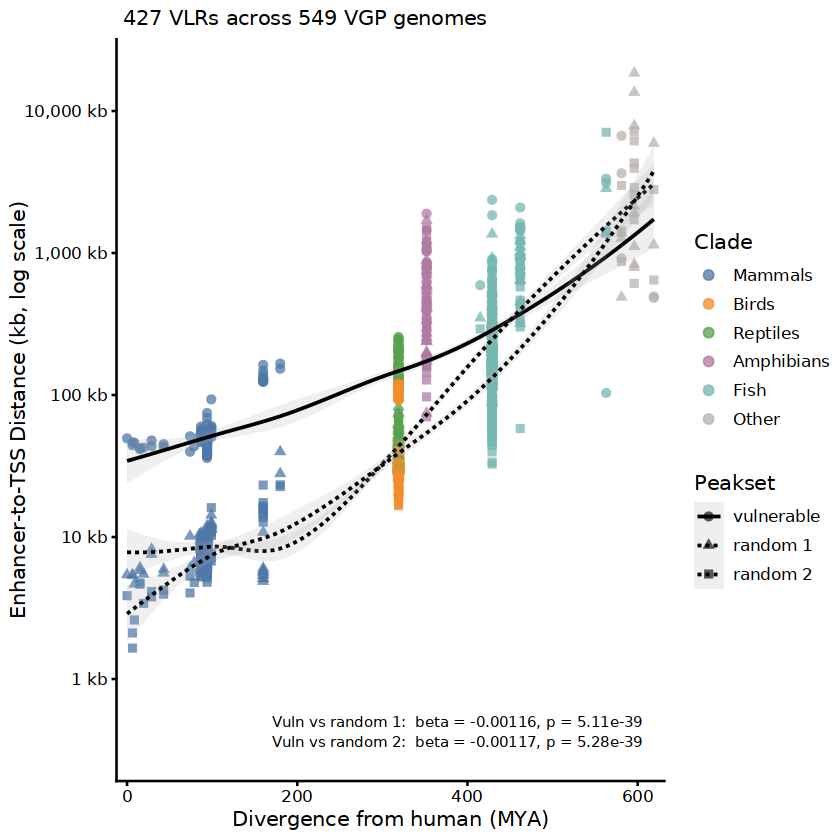

In [42]:
# Manuscript Figure 10 --------------------------------------------------------
#------------------------------------------------------------------------------

# ── Plot data ────────────────────────────────────────────────────────────────
Clade_colors <- c(
  Mammals = "#4E79A7", Birds = "#F28E2B", Reptiles = "#59A14F",
  Amphibians = "#B07AA1", Fish = "#76B7B2", Other = "#BAB0AC"
)

plot_df <- Species_stats %>%
  filter(!is.na(Div.Time.MYA)) %>%                 # & Clade != 'Other'
  mutate(
    dist_kb = pmax(median_abs_dist, 1) / 1e3,      # floor 0s so log scale keeps them
    peakset = factor(peakset, levels = c("vulnerable", "random 1", "random 2"))
  )

n_zero <- sum(Species_stats$median_abs_dist <= 0, na.rm = TRUE)
if (n_zero > 0) message(n_zero, " species floored to 1 bp for log scale.")

# ── Pairwise interaction tests: vulnerable vs EACH random, separately ─────────
# Each fit uses ONLY the two relevant peaksets, with that random as the baseline,
# so Div.Time.MYA:peaksetvulnerable = (vulnerable slope − that random's slope).
pairwise_interaction <- function(df, random_label) {
  d <- df %>%
    filter(peakset %in% c("vulnerable", random_label)) %>%
    mutate(peakset = relevel(droplevels(peakset), ref = random_label))
  m  <- lm(log10(pmax(median_abs_dist, 1)) ~ Div.Time.MYA * peakset,
           data = d, weights = n_peaks)
  rn <- grep("^Div\\.Time\\.MYA:peakset", rownames(summary(m)$coefficients), value = TRUE)
  co <- summary(m)$coefficients[rn, ]
  c(beta = unname(co["Estimate"]), p = unname(co["Pr(>|t|)"]))
}

r1 <- pairwise_interaction(plot_df, "random 1")
r2 <- pairwise_interaction(plot_df, "random 2")

lab <- sprintf(
  "Vuln vs random 1:  beta = %.3g, p = %.3g\nVuln vs random 2:  beta = %.3g, p = %.3g",
  r1["beta"], r1["p"], r2["beta"], r2["p"]
)

# ── Figure: 3 loess fits (vulnerable + 2 randoms), points colored by clade ────
p1 <- ggplot(plot_df, aes(x = Div.Time.MYA, y = dist_kb)) +
  geom_point(aes(color = Clade, shape = peakset), size = 2.2, alpha = 0.75) +
  geom_smooth(
    aes(linetype = peakset, group = peakset),
    method = "loess", se = TRUE, span = 0.9,
    linewidth = 0.8, color = "black", fill = "grey70", alpha = 0.20
  ) +
  scale_color_manual(values = Clade_colors, name = "Clade") +
  scale_shape_manual(
    values = c("vulnerable" = 16, "random 1" = 17, "random 2" = 15), name = "Peakset"
  ) +
  scale_linetype_manual(
    values = c("vulnerable" = "solid", "random 1" = "dashed", "random 2" = "dashed"),
    name = "Peakset"
  ) +
  scale_x_continuous(expand = expansion(mult = 0.02)) +
  scale_y_log10(labels = scales::label_comma(suffix = " kb")) +
  labs(
    x = "Divergence from human (MYA)",
    y = "Enhancer-to-TSS Distance (kb, log scale)",
    subtitle = paste0(" 427 VLRs across ", length(unique(Species_stats$Species)), " VGP genomes")
  ) +
  annotate("text",
    x = max(plot_df$Div.Time.MYA) * 0.98,
    y = min(plot_df$dist_kb) * 0.2,     # nudge up if it clips at the bottom edge
    label = lab, hjust = 1, vjust = 0, size = 3.0
  ) +
  theme_classic(base_size = 12)

p1
ggsave(paste0(PLOTDIR, "figure1_vuln_dist_abs_random.pdf"), p1, width = 6, height = 4.5)

Enhancer–gene pairs: 5 
Species covered:     353 

Distance shift distribution (kb):
       1%        5%       25%       50%       75%       95%       99% 
-109.5220  -47.1984   -7.7370   -4.9810    0.6440   30.7190  172.5187 

Median dist shift (kb) per cell:
        1%         5%        25%        50%        75%        95%        99% 
-126.37262  -74.31765   -7.64900   -2.10050    0.65550   22.02210  101.52847 

Fill limit set to ±10 kb


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Enhancer–gene distance shift across vertebrate species' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Enhancer–gene distance shift across vertebrate species' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Enhancer–gene distance shift across vertebrate species' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Enhancer–gene distance shift across vertebrate species' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Enhancer–gene distance shift across vertebrate species' in 'mbcsToSb

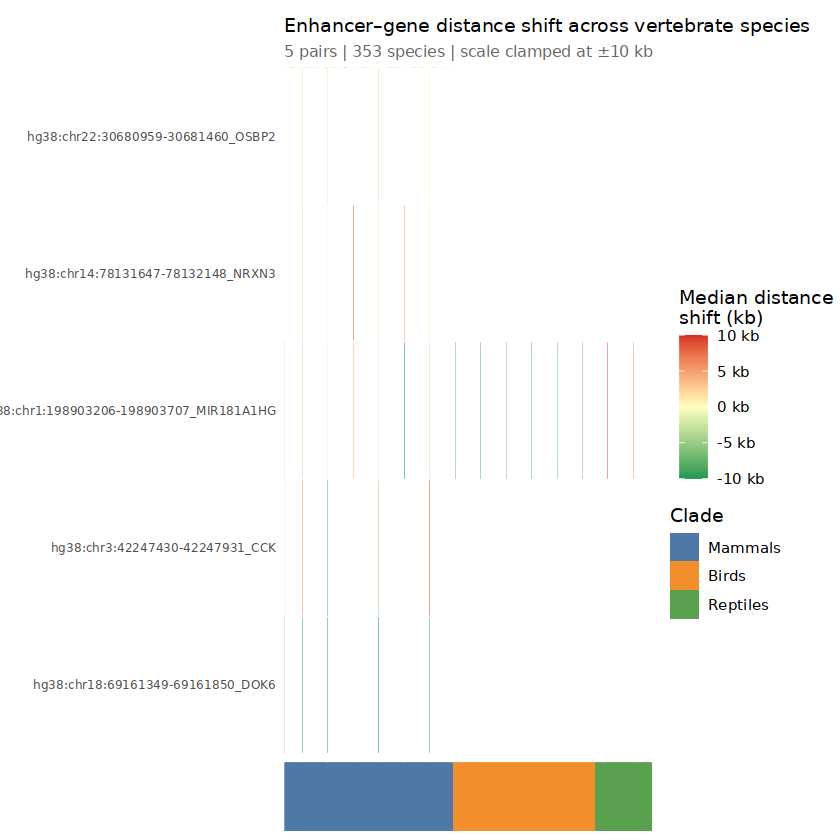

In [24]:
# Manuscript Figure 10 --------------------------------------------------------
#------------------------------------------------------------------------------

genes <- c('MIR181A1HG','CCK','NRXN3','DOK6','OSBP2')

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE — enhancer_set × species distance-shift heatmap
# NOTE: grouping is per-Species (Scientific Name). If you actually want one
#       column per ORDER, swap Species -> Orders_English_Name everywhere below.
# ══════════════════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — subset to vulnerable peaks near the target genes (anchored on hg38)
# ─────────────────────────────────────────────────────────────────────────────
synteny2 <- synteny %>%
  filter(
    peakset == "vulnerable",          # (fix #2) don't pool random into the panel
    ref_gene %in% genes,              # (fix #1) anchor on the constant hg38 gene,
    !is.na(dist_shift_bp),            #          NOT the per-genome nearest_gene
    !is.na(Species)
  ) %>%
  mutate(enhancer_set = paste0(peak_id, "_", ref_gene))
  # (fix #4) no meta join here — synteny already carries Div.Time.MYA / Species / Clade

cat("Enhancer–gene pairs:", n_distinct(synteny2$enhancer_set), "\n")
cat("Species covered:    ", n_distinct(synteny2$Species),      "\n")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — inspect the shift distribution (sets the fill limit sensibly)
# ─────────────────────────────────────────────────────────────────────────────
cat("\nDistance shift distribution (kb):\n")
print(quantile(synteny2$dist_shift_bp / 1e3,
               c(0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99), na.rm = TRUE))

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — summarise: enhancer_set × Species, order rows by conservation
# ─────────────────────────────────────────────────────────────────────────────
enhancer_order_mat <- synteny2 %>%
  group_by(enhancer_set, Species, Clade) %>%
  summarise(
    median_dist_shift_kb = median(dist_shift_bp / 1e3, na.rm = TRUE),
    n_genomes            = n_distinct(accession),
    .groups              = "drop"
  ) %>%
  group_by(enhancer_set) %>%
  mutate(mean_abs_shift = mean(abs(median_dist_shift_kb), na.rm = TRUE)) %>%
  ungroup() %>%
  # (fix, dead code) most-conserved (smallest abs shift) at TOP:
  # ggplot puts the LAST factor level at the top, so order desc by instability.
  mutate(
    enhancer_set = factor(enhancer_set,
                          levels = unique(enhancer_set[order(-mean_abs_shift)])),
    Species = factor(
      Species,
      levels = synteny2 %>% arrange(Clade, Species) %>% pull(Species) %>% unique()
    )
  )
  # (removed the second grepl filter — redundant no-op after STEP 1)

cat("\nMedian dist shift (kb) per cell:\n")
print(quantile(enhancer_order_mat$median_dist_shift_kb,
               c(0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99), na.rm = TRUE))

# (fix #3) data-driven fill limit — 90th pct of |shift|, so cells encode
#          magnitude instead of saturating. Override manually if you prefer.
#limit_kb <- signif(as.numeric(quantile(abs(enhancer_order_mat$median_dist_shift_kb),
#                                        0.75, na.rm = TRUE)), 2)   # ~8 kb here
limit_kb <- 10
cat("\nFill limit set to ±", limit_kb, " kb\n", sep = "")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — Clade annotation bar
# ─────────────────────────────────────────────────────────────────────────────
Clade_colors <- c(
  Mammals = "#4E79A7", Birds = "#F28E2B", Reptiles = "#59A14F",
  Amphibians = "#B07AA1", Fish = "#76B7B2", Other = "#BAB0AC"
)

order_Clade <- synteny2 %>%
  distinct(Species, Clade) %>%
  mutate(Species = factor(Species, levels = levels(enhancer_order_mat$Species)))

p_Clade_bar <- ggplot(order_Clade, aes(x = Species, y = 1, fill = Clade)) +
  geom_tile() +
  scale_fill_manual(values = Clade_colors, name = "Clade") +
  scale_x_discrete(expand = c(0, 0)) +
  scale_y_continuous(expand = c(0, 0)) +
  theme_void() +
  theme(
    legend.position = "right",
    axis.text.x     = element_text(angle = 45, hjust = 1, size = 8)
  )

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — main heatmap
# ─────────────────────────────────────────────────────────────────────────────
brks <- c(-limit_kb, -limit_kb/2, 0, limit_kb/2, limit_kb)

p3 <- ggplot(enhancer_order_mat,
             aes(x = Species, y = enhancer_set, fill = median_dist_shift_kb)) +
  geom_tile(color = "white", linewidth = 0.3) +
  scale_fill_gradient2(
    low = "#1a9850", mid = "#ffffbf", high = "#d73027",  # closer=green, further=red
    midpoint = 0,
    limits   = c(-limit_kb, limit_kb),
    breaks   = brks,
    labels   = paste0(brks, " kb"),
    oob      = scales::squish,
    na.value = "grey90",
    name     = "Median distance\nshift (kb)"
  ) +
  scale_x_discrete(expand = c(0, 0)) +
  scale_y_discrete(expand = c(0, 0)) +
  labs(
    x = NULL, y = NULL,
    title = "Enhancer–gene distance shift across vertebrate species",
    subtitle = paste0(
      n_distinct(enhancer_order_mat$enhancer_set), " pairs | ",
      n_distinct(enhancer_order_mat$Species), " species | scale clamped at ±",
      limit_kb, " kb"
    )
  ) +
  theme_minimal(base_size = 11) +
  theme(
    axis.text.y   = element_text(size = 7),
    axis.text.x   = element_blank(),   # column labels live in the Clade bar
    axis.ticks    = element_blank(),
    panel.grid    = element_blank(),
    plot.title    = element_text(face = "bold", size = 11),
    plot.subtitle = element_text(size = 9, color = "grey40"),
    legend.position = "right"
  )

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 — combine and save
# (fix #6) blank x only on p3 above; do NOT use `& theme(...)`, which would
#          also wipe the Clade bar's labels.
# ─────────────────────────────────────────────────────────────────────────────
fig <- p3 / p_Clade_bar +
  plot_layout(heights = c(10, 1), guides = "collect") &
  theme(
    axis.text.x  = element_blank(),
    axis.ticks.x = element_blank()
  )

fig

ggsave(
filename = paste0(PLOTDIR, "figure_enhancers_dist_abs_heatmap.pdf"),
plot = fig, width = 10, height = 4, device = cairo_pdf
)

Enhancer–gene pairs: 5 
Species covered:     353 

Absolute distance distribution (kb):
       1%        5%       25%       50%       75%       95%       99% 
  6.50244   8.92500  19.00300  26.74800  39.07500 175.53540 244.72464 

Median abs distance (kb) per cell:
       1%        5%       25%       50%       75%       95%       99% 
  8.29628   9.42015  16.18225  30.96400  40.14725 186.52595 236.95438 

Fill limit set to 100 kb


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Median enhancer–' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Median enhancer–' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Median enhancer–' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Median enhancer–' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Median enhancer–' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Median enhancer–' in 'mbcsToSbcs': dot substituted for <93>

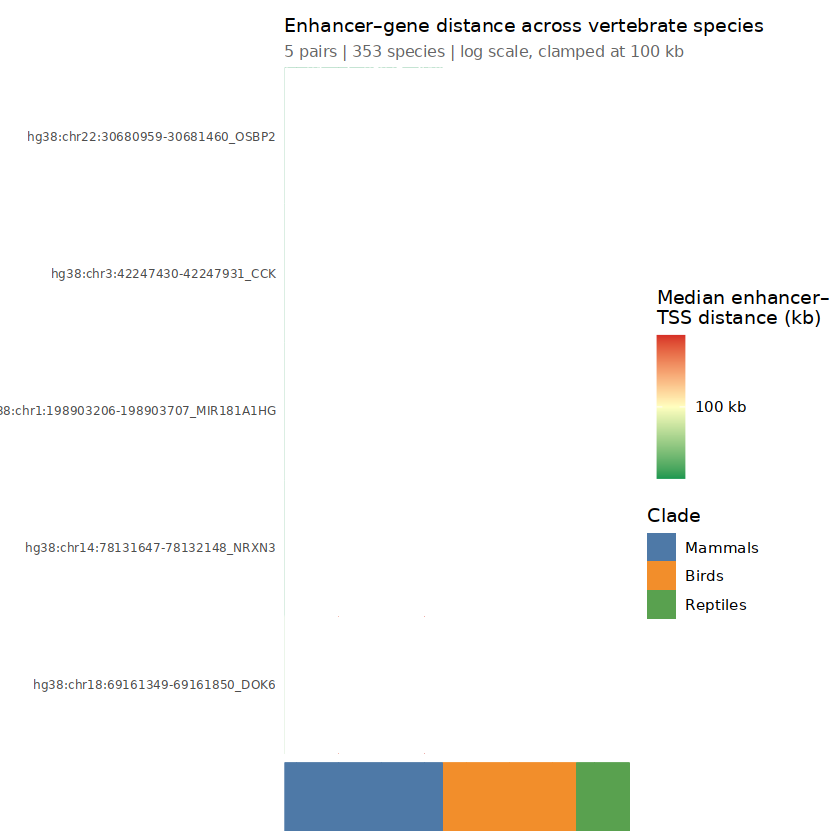

In [28]:
genes <- c('MIR181A1HG','CCK','NRXN3','DOK6','OSBP2')

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE — enhancer_set × species ABSOLUTE-distance heatmap
# NOTE: grouping is per-Species (Scientific Name). For one column per ORDER,
#       swap Species -> Orders_English_Name everywhere below.
# ══════════════════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — subset to vulnerable peaks near the target genes (anchored on hg38)
# ─────────────────────────────────────────────────────────────────────────────
synteny2 <- synteny %>%
  filter(
    peakset == "vulnerable",       # don't pool random into the panel
    ref_gene %in% genes,           # anchor on the constant hg38 gene
    !is.na(abs_dist_bp),
    !is.na(Species)
  ) %>%
  mutate(enhancer_set = paste0(peak_id, "_", ref_gene))
  # synteny already carries Div.Time.MYA / Species / Clade — no meta join needed

cat("Enhancer–gene pairs:", n_distinct(synteny2$enhancer_set), "\n")
cat("Species covered:    ", n_distinct(synteny2$Species),      "\n")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — inspect the absolute-distance distribution
# ─────────────────────────────────────────────────────────────────────────────
cat("\nAbsolute distance distribution (kb):\n")
print(quantile(synteny2$abs_dist_bp / 1e3,
               c(0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99), na.rm = TRUE))

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — summarise: enhancer_set × Species, order rows by distance
# ─────────────────────────────────────────────────────────────────────────────
enhancer_order_mat <- synteny2 %>%
  group_by(enhancer_set, Species, Clade) %>%
  summarise(
    median_abs_dist_kb = median(abs_dist_bp / 1e3, na.rm = TRUE),
    n_genomes          = n_distinct(accession),
    .groups            = "drop"
  ) %>%
  group_by(enhancer_set) %>%
  mutate(mean_abs_dist = mean(median_abs_dist_kb, na.rm = TRUE)) %>%
  ungroup() %>%
  mutate(
    # most distal enhancer at TOP (ggplot puts last level on top).
    # flip to order(mean_abs_dist) to lead with the closest instead.
    enhancer_set = factor(enhancer_set,
                          levels = unique(enhancer_set[order(-mean_abs_dist)])),
    Species = factor(
      Species,
      levels = synteny2 %>% arrange(Clade, Species) %>% pull(Species) %>% unique()
    )
  )

cat("\nMedian abs distance (kb) per cell:\n")
print(quantile(enhancer_order_mat$median_abs_dist_kb,
               c(0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99), na.rm = TRUE))

# Fill limit — check the quantiles above and set where the bulk of cells live.
# Absolute distances span orders of magnitude, so log scale is used below;
# limit_kb just caps the top end so a few huge outliers don't own the ramp.
limit_kb <- 100
cat("\nFill limit set to ", limit_kb, " kb\n", sep = "")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — Clade annotation bar
# ─────────────────────────────────────────────────────────────────────────────
Clade_colors <- c(
  Mammals = "#4E79A7", Birds = "#F28E2B", Reptiles = "#59A14F",
  Amphibians = "#B07AA1", Fish = "#76B7B2", Other = "#BAB0AC"
)

order_Clade <- synteny2 %>%
  distinct(Species, Clade) %>%
  mutate(Species = factor(Species, levels = levels(enhancer_order_mat$Species)))

p_Clade_bar <- ggplot(order_Clade, aes(x = Species, y = 1, fill = Clade)) +
  geom_tile() +
  scale_fill_manual(values = Clade_colors, name = "Clade") +
  scale_x_discrete(expand = c(0, 0)) +
  scale_y_continuous(expand = c(0, 0)) +
  theme_void() +
  theme(
    legend.position = "right",
    axis.text.x     = element_text(angle = 45, hjust = 1, size = 8)
  )

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — main heatmap (sequential, log-scaled fill)
# ─────────────────────────────────────────────────────────────────────────────
# floor zeros so log10 doesn't send on-TSS cells to -Inf (→ grey)
enhancer_order_mat <- enhancer_order_mat %>%
  mutate(median_abs_dist_kb = pmax(median_abs_dist_kb, 0.001))  # 1 bp floor, in kb

brks <- c(0.01, 0.1, 1, 10, limit_kb)

p3 <- ggplot(enhancer_order_mat,
             aes(x = Species, y = enhancer_set, fill = median_abs_dist_kb)) +
  geom_tile(color = "white", linewidth = 0.3) +
  scale_fill_gradientn(
    colors   = c("#1a9850","#ffffbf", "#d73027"),  
    trans    = "log10",
    limits   = c(50, 200),
    breaks   = brks,
    labels   = paste0(brks, " kb"),
    oob      = scales::squish,
    na.value = "grey90",
    name     = "Median enhancer–\nTSS distance (kb)"
  ) +
  scale_x_discrete(expand = c(0, 0)) +
  scale_y_discrete(expand = c(0, 0)) +
  labs(
    x = NULL, y = NULL,
    title = "Enhancer–gene distance across vertebrate species",
    subtitle = paste0(
      n_distinct(enhancer_order_mat$enhancer_set), " pairs | ",
      n_distinct(enhancer_order_mat$Species), " species | log scale, clamped at ",
      limit_kb, " kb"
    )
  ) +
  theme_minimal(base_size = 11) +
  theme(
    axis.text.y   = element_text(size = 7),
    axis.text.x   = element_blank(),   # column labels live in the Clade bar
    axis.ticks    = element_blank(),
    panel.grid    = element_blank(),
    plot.title    = element_text(face = "bold", size = 11),
    plot.subtitle = element_text(size = 9, color = "grey40"),
    legend.position = "right"
  )

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 — combine and save
# (blank x only on p3 above; NO `& theme(...)`, which would wipe the Clade bar)
# ─────────────────────────────────────────────────────────────────────────────
fig <- p3 / p_Clade_bar +
  plot_layout(heights = c(10, 1), guides = "collect") &
  theme(
    axis.text.x  = element_blank(),
    axis.ticks.x = element_blank()
  )

fig

ggsave(
  filename = paste0(PLOTDIR, "figure_enhancers_dist_abs_heatmap.pdf"),
  plot = fig, width = 10, height = 4, device = cairo_pdf
)